## Download Dataset

In [3]:
!kaggle datasets download rakeshrau/social-network-ads -p /home/midori/Desktop/Nural_Network/Data

Dataset URL: https://www.kaggle.com/datasets/rakeshrau/social-network-ads
License(s): unknown
100%|██████████████████████████████████████| 3.27k/3.27k [00:00<00:00, 7.40MB/s]



### extract zip file

In [4]:
from zipfile import ZipFile
from pathlib import Path

In [5]:
zip_path = '/home/midori/Desktop/Nural_Network/Data/social-network-ads.zip'
extrat_path = '/home/midori/Desktop/Nural_Network/Data/social_network'

In [6]:
with ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(extrat_path)
print(f'file extracted at {extrat_path}')

file extracted at /home/midori/Desktop/Nural_Network/Data/social_network


## source

In [2]:
import numpy as np
import pandas as pd
import time

In [3]:
df = pd.read_csv('../../../Data/social_network/Social_Network_Ads.csv')

In [8]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df[['Age','EstimatedSalary','Purchased']]

In [10]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:

X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled.shape

(400, 2)

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [17]:
X_train.shape

(320, 2)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Input

In [21]:
model = Sequential([
    Input(shape=(2,)), # tupil
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
type(X_scaled) == np.ndarray

True

In [ ]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=400,batch_size=1,validation_split=0.3)
#print(time.time() - start)

In [20]:
from tensorflow.keras.models import load_model

model = load_model("model1.keras")

In [21]:
# prediction
y_pred = model.predict(X_scaled)

# evaluation
model.evaluate(X_scaled, y)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9000 - loss: 0.4609  


[0.4609450399875641, 0.8999999761581421]

In [16]:
import pickle
import matplotlib.pyplot as plt

In [17]:
with open("history.pkl", "wb") as f:
    pickle.dump(history.history, f)

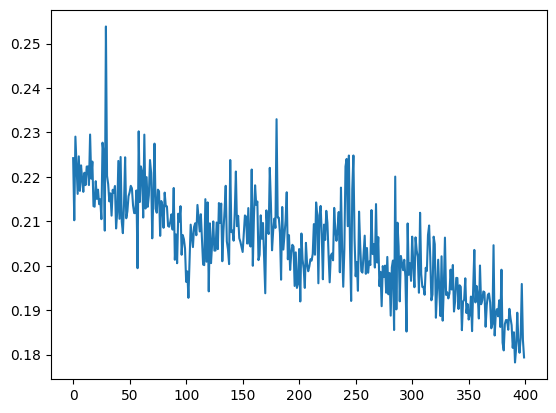

In [18]:
with open("history.pkl", "rb") as f:
    hist = pickle.load(f)

plt.plot(hist['loss'])

In [19]:
model.save('model1.keras')

## Batch

In [22]:
model2 = Sequential()

model2.add(Dense(10,activation='relu',input_dim=2))
model2.add(Dense(10,activation='relu'))
model2.add(Dense(1,activation='sigmoid'))

/home/midori/Desktop/Nural_Network/nural_venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history2 = model2.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.3)
#print(time.time() - start)

In [28]:
with open("history2.pkl", "wb") as f:
    pickle.dump(history2.history, f)

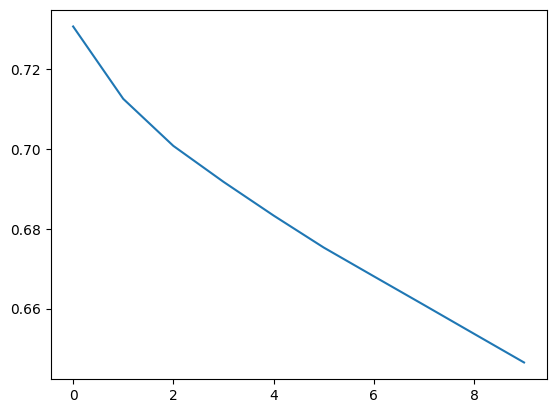

In [29]:
with open("history2.pkl", "rb") as f:
    hist = pickle.load(f)

plt.plot(hist['loss'])